# 02 LightGBM

In [1]:
%matplotlib inline
import json, os, warnings
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from lightgbm import LGBMRegressor, early_stopping, log_evaluation
from sklearn.metrics import mean_absolute_error, mean_squared_error
warnings.filterwarnings("ignore")

from data_loader_00 import load_processed_data, get_Xy, get_combos

OUTPUT_DIR = os.path.join(os.getcwd(), "outputs")
os.makedirs(OUTPUT_DIR, exist_ok=True)
RANDOM_SEED = 42
LGBM_PARAM_GRID = [
    {
        "learning_rate": lr,
        "num_leaves": nl,
        "max_depth": md,
        "n_estimators": ne,
        "min_child_samples": 20,
        "subsample": 0.8,
        "colsample_bytree": 0.8,
        "reg_alpha": ra,
        "reg_lambda": 1.0,
    }
    for lr in [0.03, 0.05, 0.1]
    for nl in [31, 63, 127]
    for md in [5, 8, -1]
    for ne in [300, 600]
    for ra in [0.0, 0.1]
]

In [2]:
def calc_metrics(y_true, y_pred, label=""):
    y_true = np.array(y_true, dtype=float)
    y_pred = np.array(y_pred, dtype=float)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / np.where(y_true == 0, 1, y_true))) * 100
    denom = np.sum((y_true - y_true.mean()) ** 2)
    r2 = np.nan if denom == 0 else 1 - np.sum((y_true - y_pred) ** 2) / denom
    if label:
        print(f"[{label}] MAE={mae:,.2f} RMSE={rmse:,.2f} MAPE={mape:.3f}% R2={r2:.4f}")
    return {"MAE": round(mae, 2), "RMSE": round(rmse, 2), "MAPE": round(mape, 3), "R2": round(float(r2), 4)}

def tune_pooled_lgbm(train, valid, test, feature_cols):
    X_tr, y_tr = get_Xy(train, feature_cols)
    X_va, y_va = get_Xy(valid, feature_cols)
    X_te, y_te = get_Xy(test, feature_cols)
    results = []
    for params in LGBM_PARAM_GRID:
        p = params.copy()
        n_estimators = p.pop("n_estimators")
        model = LGBMRegressor(**p, n_estimators=n_estimators, random_state=RANDOM_SEED, verbose=-1)
        model.fit(
            X_tr, y_tr,
            eval_set=[(X_va, y_va)],
            eval_metric="l1",
            callbacks=[early_stopping(stopping_rounds=40, verbose=False), log_evaluation(period=0)],
        )
        valid_preds = model.predict(X_va, num_iteration=model.best_iteration_)
        valid_mae = mean_absolute_error(y_va, valid_preds)
        results.append({**params, "best_iter": int(model.best_iteration_ or n_estimators), "valid_MAE": round(valid_mae, 4)})
    df_res = pd.DataFrame(results).sort_values("valid_MAE").reset_index(drop=True)
    best_row = df_res.iloc[0]
    best_params = {
        "learning_rate": float(best_row["learning_rate"]),
        "num_leaves": int(best_row["num_leaves"]),
        "max_depth": int(best_row["max_depth"]),
        "n_estimators": int(best_row["best_iter"]),
        "min_child_samples": 20,
        "subsample": 0.8,
        "colsample_bytree": 0.8,
        "reg_alpha": float(best_row["reg_alpha"]),
        "reg_lambda": 1.0,
    }
    X_trva = np.vstack([X_tr, X_va])
    y_trva = np.concatenate([y_tr, y_va])
    best_model = LGBMRegressor(**best_params, random_state=RANDOM_SEED, verbose=-1)
    best_model.fit(X_trva, y_trva)
    test_preds = best_model.predict(X_te)
    return best_model, df_res, best_params, y_te, test_preds

In [3]:
train, valid, test, feature_cols = load_processed_data(valid_weeks=8)
best_model, df_res, best_params, y_te, pooled_preds = tune_pooled_lgbm(train, valid, test, feature_cols)
pooled_metrics = calc_metrics(y_te, pooled_preds, label="LGBM-Pooled test")
print(best_params)

[load] Train=6,270 | Valid=240 | Test=240 | Features=23
[LGBM-Pooled test] MAE=456.27 RMSE=824.57 MAPE=4.512% R2=0.9896
{'learning_rate': 0.1, 'num_leaves': 31, 'max_depth': -1, 'n_estimators': 97, 'min_child_samples': 20, 'subsample': 0.8, 'colsample_bytree': 0.8, 'reg_alpha': 0.1, 'reg_lambda': 1.0}


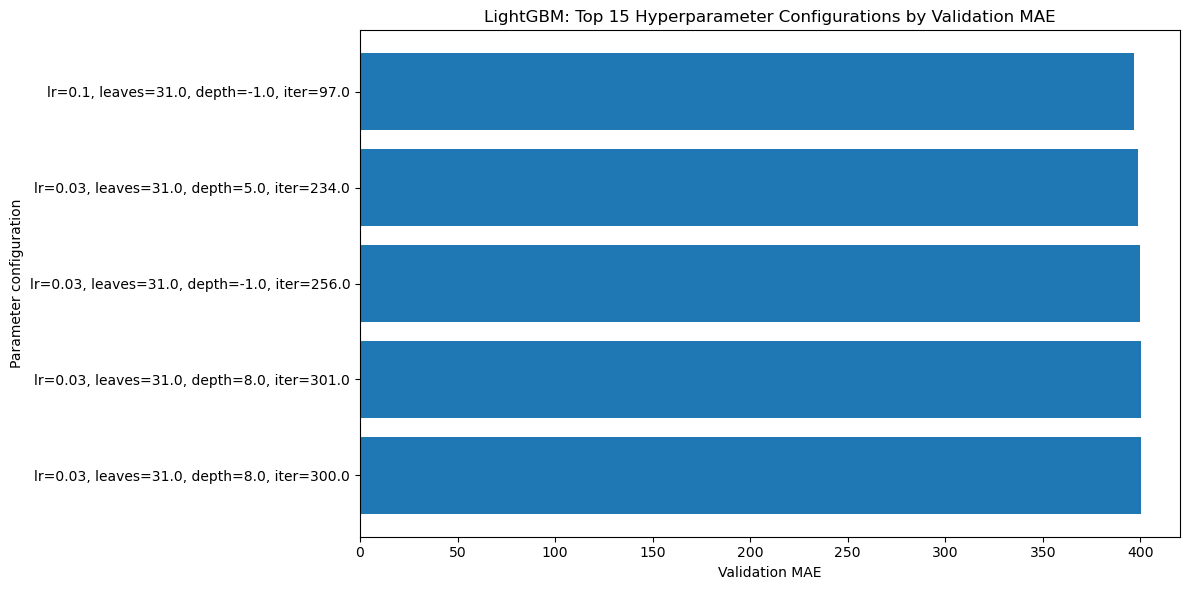

In [4]:
top15 = df_res.nsmallest(15, "valid_MAE").copy()
top15["config"] = [
    f"lr={r.learning_rate}, leaves={r.num_leaves}, depth={r.max_depth}, iter={r.best_iter}"
    for _, r in top15.iterrows()
]

plt.figure(figsize=(12, 6))
plt.barh(top15["config"][::-1], top15["valid_MAE"][::-1])
plt.title("LightGBM: Top 15 Hyperparameter Configurations by Validation MAE")
plt.xlabel("Validation MAE")
plt.ylabel("Parameter configuration")
plt.tight_layout()
plt.show()

In [5]:
joblib.dump(best_model, os.path.join(OUTPUT_DIR, "lgbm_pooled_best_model.joblib"))
df_res.to_csv(os.path.join(OUTPUT_DIR, "lgbm_sensitivity_table.csv"), index=False)
print("Saved LGBM outputs.")

Saved LGBM outputs.
